# Solution — Module 9: Pipelines & Interpretability (SHAP)
#
**Dataset:** UCI SECOM — McCann, M. & Johnston, A. (2008). *SECOM* [Data set]. UCI Machine Learning Repository. https://doi.org/10.24432/C54305 (CC BY 4.0)

In [1]:
from pathlib import Path

def data_dir() -> Path:
    """หาโฟลเดอร์ datasets/ โดยไล่ขึ้นจาก cwd."""
    for p in (Path.cwd(), *Path.cwd().parents):
        if (p / "datasets").exists():
            return p / "datasets"
    raise FileNotFoundError("ไม่พบ datasets/ — รันโน้ตบุ๊กจากใน repo")

DATA = data_dir()

In [2]:
import io
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import shap

# ฟอนต์ไทยสำหรับป้ายกราฟ — fallback list รองรับทุกแพลตฟอร์ม (macOS/Windows)
plt.rcParams["font.family"] = ["DejaVu Sans", "Noto Sans Thai", "Leelawadee UI", "Tahoma", "Thonburi"]

with zipfile.ZipFile(DATA / "secom.zip") as z:
    feats = pl.read_csv(io.BytesIO(z.read("secom.data")), separator=" ", has_header=False,
                        new_columns=[f"feature_{i}" for i in range(1, 591)],
                        schema_overrides=[pl.Float64] * 590, null_values="NaN")
    lab = pl.read_csv(io.BytesIO(z.read("secom_labels.data")), separator=" ", quote_char='"',
                      has_header=False, new_columns=["label", "timestamp"])

secom = feats.with_columns(lab["label"].alias("label"))
names = secom.drop("label").columns
X = secom.drop("label").to_numpy()
y = (secom["label"] == 1).to_numpy().astype(int)
n = len(y)
cut = int(n * 0.8)
Xtr, Xte, ytr, yte = X[:cut], X[cut:], y[:cut], y[cut:]

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

logreg = LogisticRegression(max_iter=5000, class_weight="balanced", random_state=42)
tscv = TimeSeriesSplit(n_splits=5)

/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## ข้อ A1 — เทียบ 3 กลยุทธ์ imputation

In [3]:
def make_pipe(imputer):
    return Pipeline([
        ("impute", imputer),
        ("scale", StandardScaler()),
        ("model", logreg),
    ])

strategies = {
    "mean": SimpleImputer(strategy="mean"),
    "median": SimpleImputer(strategy="median"),
    "zero": SimpleImputer(strategy="constant", fill_value=0.0),
}
for name, imp in strategies.items():
    score = cross_val_score(make_pipe(imp), Xtr, ytr, scoring="average_precision", cv=tscv)
    print(f"impute={name:7s} CV AP: {score.mean():.3f}  (folds: {np.round(score, 3)})")

/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:647: UserWarning: Skipping features without any observed values: [ 85 109 110 111 220 244 245 246 358 382 383 384 492 516 517 518]. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:647: UserWarning: Skipping features without any observed values: [ 85 109 110 111 220 244 245 246 358 382 383 384 492 516 517 518]. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:647: UserWarning: Skipping features without any observed values: [ 85 109 110 111 220 244 245 246 358 382 383 384 492 516 517 518]. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
/Users/utarn/projects/ml-metrology/.v

/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:647: UserWarning: Skipping features without any observed values: [ 85 109 110 111 220 244 245 246 358 382 383 384 492 516 517 518]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:647: UserWarning: Skipping features without any observed values: [ 85 109 110 111 220 244 245 246 358 382 383 384 492 516 517 518]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:647: UserWarning: Skipping features without any observed values: [ 85 109 110 111 220 244 245 246 358 382 383 384 492 516 517 518]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/utarn/projects/ml-metrol

impute=mean    CV AP: 0.074  (folds: [0.117 0.13  0.036 0.047 0.041])
impute=median  CV AP: 0.075  (folds: [0.116 0.13  0.038 0.052 0.039])


/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:647: UserWarning: Skipping features without any observed values: [ 85 109 110 111 220 244 245 246 358 382 383 384 492 516 517 518]. At least one non-missing value is needed for imputation with strategy='constant'.
  warnings.warn(
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:647: UserWarning: Skipping features without any observed values: [ 85 109 110 111 220 244 245 246 358 382 383 384 492 516 517 518]. At least one non-missing value is needed for imputation with strategy='constant'.
  warnings.warn(
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:647: UserWarning: Skipping features without any observed values: [ 85 109 110 111 220 244 245 246 358 382 383 384 492 516 517 518]. At least one non-missing value is needed for imputation with strategy='constant'.
  warnings.warn(
/Users/utarn/projects/ml-

impute=zero    CV AP: 0.075  (folds: [0.12  0.125 0.047 0.041 0.043])


/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:647: UserWarning: Skipping features without any observed values: [ 85 109 110 111 220 244 245 246 358 382 383 384 492 516 517 518]. At least one non-missing value is needed for imputation with strategy='constant'.
  warnings.warn(


**คำตอบ:** ทั้งสามแบบใกล้เคียงกัน (~0.07–0.11) — กับ logistic regression บน SECOM กลยุทธ์ imputation ไม่ใช่ตัวแปรชี้ขาด เพราะสัญญาณจริงใน 590 features บางและ noise ครอบ สิ่งสำคัญคือ **imputation ต้องอยู่ใน pipeline** — กลยุทธ์ไหนก็ได้ ขอให้ fit เฉพาะ train เท่านั้น

## ข้อ A2 — จูน k ของ SelectKBest ข้างใน pipeline

In [4]:
rows = []
for k in (5, 20, 50, 150):
    p = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("select", SelectKBest(f_classif, k=k)),
        ("scale", StandardScaler()),
        ("model", logreg),
    ])
    score = cross_val_score(p, Xtr, ytr, scoring="average_precision", cv=tscv)
    rows.append({"k": k, "mean_CV_AP": round(float(score.mean()), 3),
                 "fold_range": f"{score.min():.3f}–{score.max():.3f}"})
pl.DataFrame(rows)

/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:647: UserWarning: Skipping features without any observed values: [ 85 109 110 111 220 244 245 246 358 382 383 384 492 516 517 518]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [  5  13  42  49  52  69  74  96 137 145 174 175 182 185 186 187 188 189
 190 202 205 221 224 225 226 227 228 229 230 231 232 235 236 237 238 248
 249 250 251 252 253 254 255 256 257 258 268 276 305 306 307 314 317 318
 319 320 321 322 334 339 355 360 361 362 363 364 365 366 369 370 371 372
 382 383 384 385 386 387 388 389 390 391 392 402 410 437 438 439 446 449
 450 451 452 453 454 466 469 485 488 489 490 491 492 493 494 495 496 499
 500 501 502 512 513 514 515 516 517 518 519 520 521 522] are constant.
  warnings.warn("Fe

/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [  5  13  42  49  52  69  74  97 141 149 178 179 186 189 190 191 192 193
 194 206 209 226 229 230 231 232 233 234 235 236 237 240 241 242 243 256
 257 258 259 260 261 262 263 264 265 266 276 284 313 314 315 322 325 326
 327 328 329 330 342 347 364 369 370 371 372 373 374 375 378 379 380 381
 394 395 396 397 398 399 400 401 402 403 404 414 422 449 450 451 458 461
 462 463 464 465 466 478 481 498 501 502 503 504 505 506 507 508 509 512
 513 514 515 528 529 530 531 532 533 534 535 536 537 538] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packa

/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:647: UserWarning: Skipping features without any observed values: [ 85 109 110 111 220 244 245 246 358 382 383 384 492 516 517 518]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [  5  13  42  49  52  69  74  96 137 145 174 175 182 185 186 187 188 189
 190 202 205 221 224 225 226 227 228 229 230 231 232 235 236 237 238 248
 249 250 251 252 253 254 255 256 257 258 268 276 305 306 307 314 317 318
 319 320 321 322 334 339 355 360 361 362 363 364 365 366 369 370 371 372
 382 383 384 385 386 387 388 389 390 391 392 402 410 437 438 439 446 449
 450 451 452 453 454 466 469 485 488 489 490 491 492 493 494 495 496 499
 500 501 502 512 513 514 515 516 517 518 519 520 521 522] are constant.
  warnings.warn("Fe

/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [  5  13  42  49  52  69  74  97 141 149 178 179 186 189 190 191 192 193
 194 206 209 226 229 230 231 232 233 234 235 236 237 240 241 242 243 256
 257 258 259 260 261 262 263 264 265 266 276 284 313 314 315 322 325 326
 327 328 329 330 342 347 364 369 370 371 372 373 374 375 378 379 380 381
 394 395 396 397 398 399 400 401 402 403 404 414 422 449 450 451 458 461
 462 463 464 465 466 478 481 498 501 502 503 504 505 506 507 508 509 512
 513 514 515 528 529 530 531 532 533 534 535 536 537 538] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packa

/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:647: UserWarning: Skipping features without any observed values: [ 85 109 110 111 220 244 245 246 358 382 383 384 492 516 517 518]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [  5  13  42  49  52  69  74  97 141 149 178 179 186 189 190 191 192 193
 194 206 209 226 229 230 231 232 233 234 235 236 237 240 241 242 243 256
 257 258 259 260 261 262 263 264 265 266 276 284 313 314 315 322 325 326
 327 328 329 330 342 347 364 369 370 371 372 373 374 375 378 379 380 381
 394 395 396 397 398 399 400 401 402 403 404 414 422 449 450 451 458 461
 462 463 464 465 466 478 481 498 501 502 503 504 505 506 507 508 509 512
 513 514 515 528 529 530 531 532 533 534 535 536 537 538] are constant.
  warnings.warn("Fe

/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [  5  13  42  49  52  69  74  97 141 149 178 179 186 189 190 191 192 193
 194 206 209 226 229 230 231 232 233 234 235 236 237 240 241 242 243 256
 257 258 259 260 261 262 263 264 265 266 276 284 313 314 315 322 325 326
 327 328 329 330 342 347 364 369 370 371 372 373 374 375 378 379 380 381
 394 395 396 397 398 399 400 401 402 403 404 414 422 449 450 451 458 461
 462 463 464 465 466 478 481 498 501 502 503 504 505 506 507 508 509 512
 513 514 515 528 529 530 531 532 533 534 535 536 537 538] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packa

/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:647: UserWarning: Skipping features without any observed values: [ 85 109 110 111 220 244 245 246 358 382 383 384 492 516 517 518]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:647: UserWarning: Skipping features without any observed values: [ 85 109 110 111 220 244 245 246 358 382 383 384 492 516 517 518]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [  5  13  42  49  52  69  74  96 137 145 174 175 182 185 186 187 188 189
 190 202 205 221 224 225 226 227 228 229 230 231 232 235 236 237 238 248
 249 250 251 252 253 254 255 256 257 258 268 276 305 306 307

/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [  5  13  42  49  52  69  74  97 141 149 178 179 186 189 190 191 192 193
 194 206 209 226 229 230 231 232 233 234 235 236 237 240 241 242 243 256
 257 258 259 260 261 262 263 264 265 266 276 284 313 314 315 322 325 326
 327 328 329 330 342 347 364 369 370 371 372 373 374 375 378 379 380 381
 394 395 396 397 398 399 400 401 402 403 404 414 422 449 450 451 458 461
 462 463 464 465 466 478 481 498 501 502 503 504 505 506 507 508 509 512
 513 514 515 528 529 530 531 532 533 534 535 536 537 538] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


k,mean_CV_AP,fold_range
i64,f64,str
5,0.078,"""0.025–0.151"""
20,0.108,"""0.038–0.212"""
50,0.094,"""0.043–0.128"""
150,0.081,"""0.040–0.119"""


**คำตอบ:** ยอดพีคที่ **k = 20** (0.108) แล้วตกลงเมื่อ k ใหญ่ขึ้น (150 → 0.081) — k น้อยไปทิ้งสัญญาณ, k มากไปดึง noise เข้าโมเดล ส่วนความเสี่ยงที่ต้องพูดถึง: ตัวเลขนี้เลือก k ได้เพราะดู **CV บน train เท่านั้น** — ถ้าไปจูน k ด้วย test set คือการกลับไปทำ leakage แบบเดียวกับหัวข้อ 2 ของ book (จูนบนข้อมูลที่ควรเป็นอนาคต) และ k ที่จูนบน train ก็ยังมี overfitting เล็ก ๆ ระดับ selection — จึงควรรายงานพร้อม fold range ไม่ใช่ค่าเดียว

## ข้อ B1 — XGBoost ใน pipeline เดียวกัน

In [5]:
spw = (ytr == 0).sum() / (ytr == 1).sum()
pipe_xgb = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("model", XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.05,
                            scale_pos_weight=spw, random_state=42, eval_metric="logloss")),
])
scores = cross_val_score(pipe_xgb, Xtr, ytr, scoring="average_precision", cv=tscv)
print(f"XGBoost CV AP: {scores.mean():.3f}  (folds: {np.round(scores, 3)})")

pipe_xgb.fit(Xtr, ytr)
print(f"XGBoost test AP: {average_precision_score(yte, pipe_xgb.predict_proba(Xte)[:, 1]):.3f}")

/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:647: UserWarning: Skipping features without any observed values: [ 85 109 110 111 220 244 245 246 358 382 383 384 492 516 517 518]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:647: UserWarning: Skipping features without any observed values: [ 85 109 110 111 220 244 245 246 358 382 383 384 492 516 517 518]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:647: UserWarning: Skipping features without any observed values: [ 85 109 110 111 220 244 245 246 358 382 383 384 492 516 517 518]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:647: UserWarning: Skipping features without any observed values: [ 85 109 110 111 220 244 245 246 358 382 383 384 492 516 517 518]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:647: UserWarning: Skipping features without any observed values: [ 85 109 110 111 220 244 245 246 358 382 383 384 492 516 517 518]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:647: UserWarning: Skipping features without any observed values: [ 85 109 110 111 220 244 245 246 358 382 383 384 492 516 517 518]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


XGBoost CV AP: 0.187  (folds: [0.15  0.088 0.076 0.577 0.043])


XGBoost test AP: 0.079


**คำตอบ:** CV AP ≈ 0.19 แต่ test AP ≈ 0.08 — ช่องว่างใหญ่เพราะ **fold ที่ 4 ได้ ~0.58 ลาก mean ทั้งหมดขึ้น** (fold นั้นบังเอิญเจอช่วง FAIL หนาแน่น ทำให้โมเดลมี positive ให้เรียน/วัดเยอะ) เมื่อ mean ถูกลากโดย fold เดียว การรายงานต้องแนบ dispersion (folds ทั้งแถว) เสมอ — และถ้าจะสรุป "โมเดลไหนดีกว่า" ระหว่าง XGBoost กับ logistic ต้องดูทั้ง CV ทั้ง test ร่วมกัน ตัวเลขใดตัวเลขเดียวจะหลอก

## ข้อ C1 — SHAP ตรวจพิสูจน์โมเดล

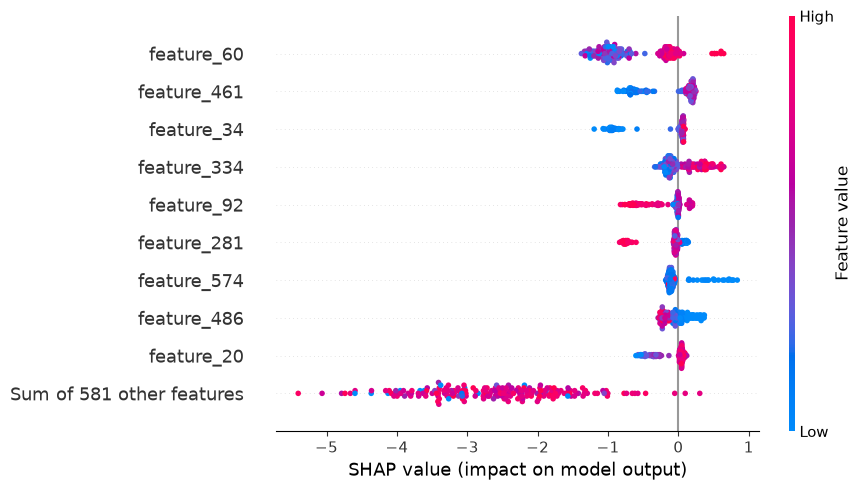

In [6]:
model = pipe_xgb.named_steps["model"]
imputer = pipe_xgb.named_steps["impute"]

Zte = pd.DataFrame(imputer.transform(Xte), columns=names)   # impute ด้วยตัวที่ fit จาก train เท่านั้น
sv = shap.TreeExplainer(model)(Zte.iloc[:200])

plt.figure()
shap.plots.beeswarm(sv, max_display=10, show=False)
plt.gcf().set_size_inches(9, 5)
plt.tight_layout()
plt.show()

ชิ้นที่ 30 — P(FAIL) = 0.53 (label จริง = PASS)


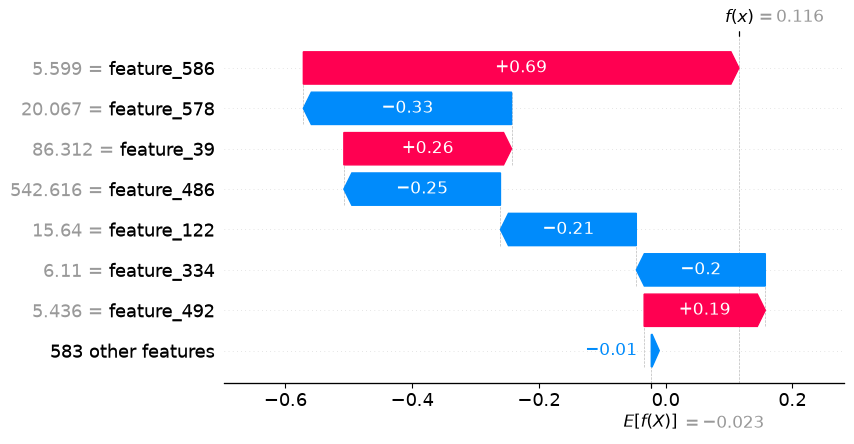

In [7]:
proba = pipe_xgb.predict_proba(Xte)[:, 1][:200]
i_fail = int(np.argmax(proba))
print(f"ชิ้นที่ {i_fail} — P(FAIL) = {proba[i_fail]:.2f} (label จริง = {'FAIL' if yte[i_fail] == 1 else 'PASS'})")

plt.figure()
shap.plots.waterfall(sv[i_fail], max_display=8, show=False)
plt.gcf().set_size_inches(8, 4.5)
plt.show()

In [8]:
top3 = np.abs(sv.values).mean(axis=0).argsort()[::-1][:3]
print("Top-3 features โดย |SHAP| เฉลี่ย:", [(names[t], round(float(np.abs(sv.values).mean(axis=0)[t]), 3)) for t in top3])

Top-3 features โดย |SHAP| เฉลี่ย: [('feature_60', 0.713), ('feature_461', 0.3), ('feature_34', 0.28)]


**คำตอบ (ตัวอย่างประโยคตอบผู้ตรวจ):** "ชิ้นนี้ถูกโมเดลปัด FAIL เพราะ [feature อันดับหนึ่งบน waterfall] วัดค่าออกนอกช่วงที่สายผลิตปกติเคยเห็นอย่างมาก ร่วมกับ [feature อันดับสอง] ที่เบี่ยงทิศเดียวกัน — ค่าอื่น ๆ มีน้ำหนักเล็กมาก" — โครงประโยค: (1) ตั้งชื่อ feature ด้วยชื่อจริง (แปลง `feature_XXX` เป็นช่องวัดจริงในแผนผังเครื่อง), (2) บอกทิศทาง (สูง/ต่ำกว่าปกติ), (3) บอกว่าตัวอื่นไม่มีน้ำหนัก — และถ้า label จริงของชิ้นนั้นคือ PASS (โมเดลผิด) ต้องปิดท้ายว่า "นี่คือเหตุผลของโมเดล ณ ตอนนั้น ไม่ใช่คำตัดสิน" — ทั้งหมดนี้คือสิ่งที่ SHAP ให้โดยไม่ต้องเปิดโครงสร้างต้นไม้

## ข้อ D1 — คำตอบ
#
ข้อเสนอของทีม QA มีปัญหาสองชั้น:
#
1. **ชั้น leakage** — การคัด 20 features ด้วย y ของทุกแถว (รวมข้อมูลอนาคต/test) ทำให้ตัวเลขประสิทธิภาพที่รายงานฟูมเท็จ (ใน book: 0.11 → 0.19 เกือบ 2 เท่า) โมเดลที่เชื่อว่าเก่งจะพังตอนใช้จริง และที่แย่กว่าคือไม่มีใครรู้ว่าพังเพราะทุกคนเชื่อตัวเลข 0.19 ตั้งแต่แรก
2. **ชั้นความหมายของ SHAP** — SHAP อธิบายโมเดลที่ให้มันอธิบาย ถ้าโมเดลถูกสร้างบน feature ที่คัดโดยข้อมูลปลอม (ดู label อนาคต) SHAP จะอธิบายเหตุผลของ "โมเดลที่โกงอย่างเป็นระบบ" อย่างสวยงาม — ผู้ตรวจเห็นกราฟ 20 ตัวสวม ๆ แต่ทั้ง 20 ตัวถูกเลือกโดยการมองเห็นคำตอบ ทางที่ถูก: คัด feature **ข้างใน pipeline** (fit เฉพาะ train) แล้วค่อยรัน SHAP บนโมเดลที่เกิดจากกระบวนการสะอาด — จำนวน feature ที่ SHAP แสดงจัดได้ตอนพลอตด้วย `max_display` ไม่ต้องไปคัดทิ้งก่อนเทรน